In [1]:
import pandas as pd
from supabase import create_client, Client
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()

url = os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_KEY')
supabase = create_client(supabase_url=url, supabase_key=key)

In [2]:
response = (
    supabase.table("logs")
    .select("*")
    .gt("created_at", ["2024-08-16 16:30:12.052344+00"])
    .in_("client_name", [
        "qiushi-developer",
        "joon-developer",
        "langdon-nextjs-development",
        "strapi-deployment",
        "langdon-developer",
        "research-methods-in-psychology",
        "middle_georgia",
    ])
    .eq("api_endpoint", "/score/summary/stairs")
    .execute()
)
data = response.data

In [3]:
df1 = pd.DataFrame(data)
df2 = pd.json_normalize(df1["request_body"])
df3 = pd.json_normalize(df1["response_body"])
df = pd.concat([df1, df2, df3], axis=1)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.set_index('created_at')
df

,id,api_endpoint,request_method,status_code,client_name,request_body,response_body,ttft,process_time,summary,...,metrics.containment.name,metrics.containment.score,metrics.containment.feedback,metrics.containment.is_passed,metrics.containment.threshold,metrics.containment_chat.name,metrics.containment_chat.score,metrics.containment_chat.feedback,metrics.containment_chat.is_passed,metrics.containment_chat.threshold
created_at,,,,,,,,,,,,,,,,,,,,,
2024-09-18 06:30:36.114969+00:00,10894,/score/summary/stairs,POST,200,middle_georgia,{'summary': 'tion process and beyond. Address ...,{'text': ' What is the primary concern that t...,0.349883,1.239897,tion process and beyond. Address publication c...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-09 22:16:33.753932+00:00,10497,/score/summary/stairs,POST,200,middle_georgia,{'summary': 'ientific method is that it cannot...,{'text': ' What does the author mean by stati...,1.120379,1.757797,ientific method is that it cannot be used to a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 06:32:29.934902+00:00,10895,/score/summary/stairs,POST,200,middle_georgia,{'summary': 'tion process and beyond. Address ...,{'text': ' What additional guidance or advice...,0.328229,1.092829,tion process and beyond. Address publication c...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 06:59:57.648135+00:00,10896,/score/summary/stairs,POST,200,middle_georgia,{'summary': 'ally important points. Researcher...,{'text': ' What do you think the author will ...,3.383444,4.226393,ally important points. Researchers should not ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 07:00:10.676358+00:00,10898,/score/summary/stairs,POST,200,middle_georgia,"{'summary': 'acceptable. However, researchers ...",{'text': ' How do the principles of humane tr...,0.468411,1.167554,"acceptable. However, researchers must use alte...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-21 21:43:25.006464+00:00,16985,/score/summary/stairs,POST,200,research-methods-in-psychology,{'summary': 'The above page is about generatin...,{'prompt': 'Excellent job summarizing the text...,NaN,2.570773,The above page is about generating good resear...,...,Language Borrowing,0.1000,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6
2025-01-21 21:48:55.213960+00:00,16987,/score/summary/stairs,POST,200,research-methods-in-psychology,{'summary': 'This page is primarily about the ...,{'prompt': 'Excellent job summarizing the text...,NaN,2.653297,This page is primarily about the difference be...,...,Language Borrowing,0.0000,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6
2025-01-21 21:55:51.323946+00:00,16990,/score/summary/stairs,POST,200,research-methods-in-psychology,{'summary': 'This page is about how to design ...,{'prompt': 'Excellent job summarizing the text...,NaN,2.539824,This page is about how to design a research st...,...,Language Borrowing,0.1136,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6


<Axes: xlabel='created_at'>

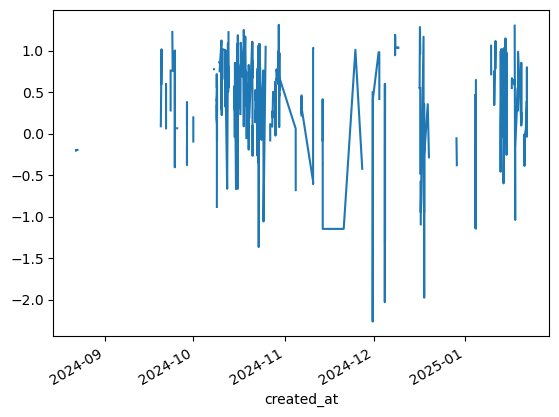

In [4]:
df['content'].fillna(df['metrics.content.score'], inplace=True)

df.content.plot()

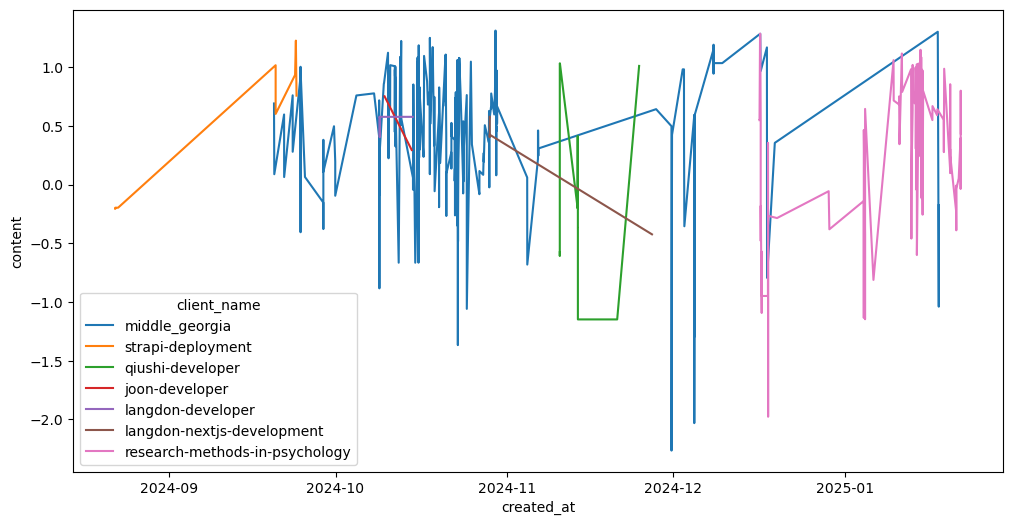

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='created_at', y='content', hue="client_name");

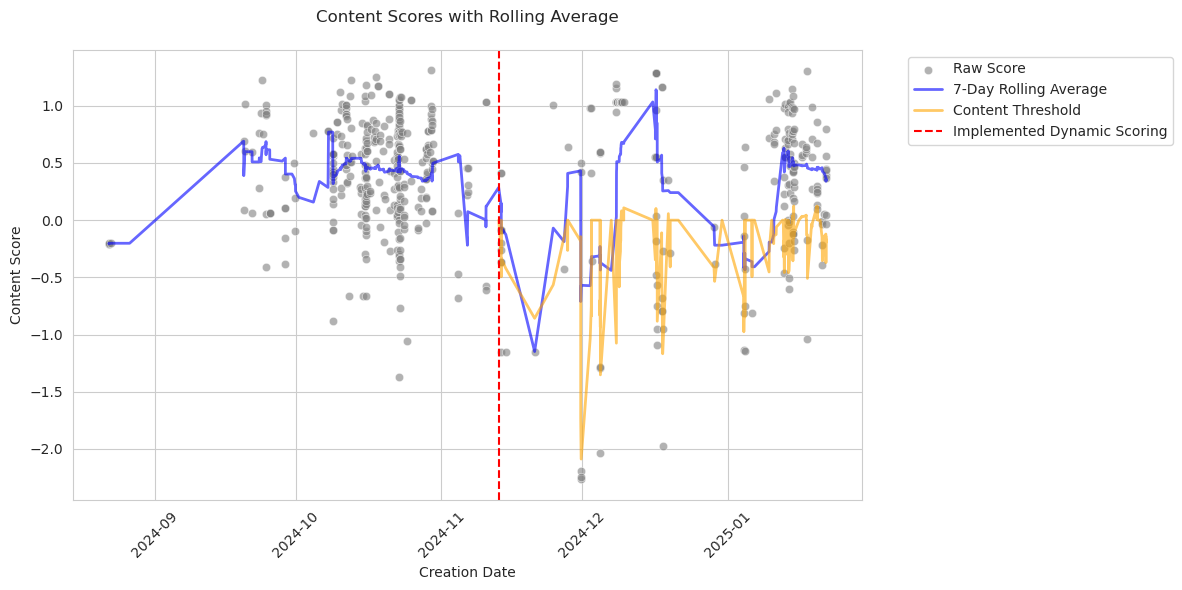

In [7]:
df = df.sort_values('created_at')

# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Create the main line plot
sns.scatterplot(data=df, x='created_at', y='content', 
             label='Raw Score', alpha=0.6, color='gray')

# Calculate and plot rolling average (7-day window)
rolling_avg = df['content'].rolling(window="7D", min_periods=1).mean()
sns.lineplot(x=df.index, y=rolling_avg, 
             label='7-Day Rolling Average', 
             color='blue', linewidth=2, alpha=0.6)

# Draw Threshold
sns.lineplot(data=df, x='created_at', y='metrics.content.threshold', 
             label='Content Threshold', 
             color='orange', linewidth=2, alpha=0.6)

# Customize the plot
plt.title('Content Scores with Rolling Average', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Indicate when we started dynamic scoring
implementation_date = pd.to_datetime("2024-11-13 05:17:11.410141+00")
plt.axvline(
    implementation_date,
    color="red",
    linestyle="--",
    label="Implemented Dynamic Scoring"
)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

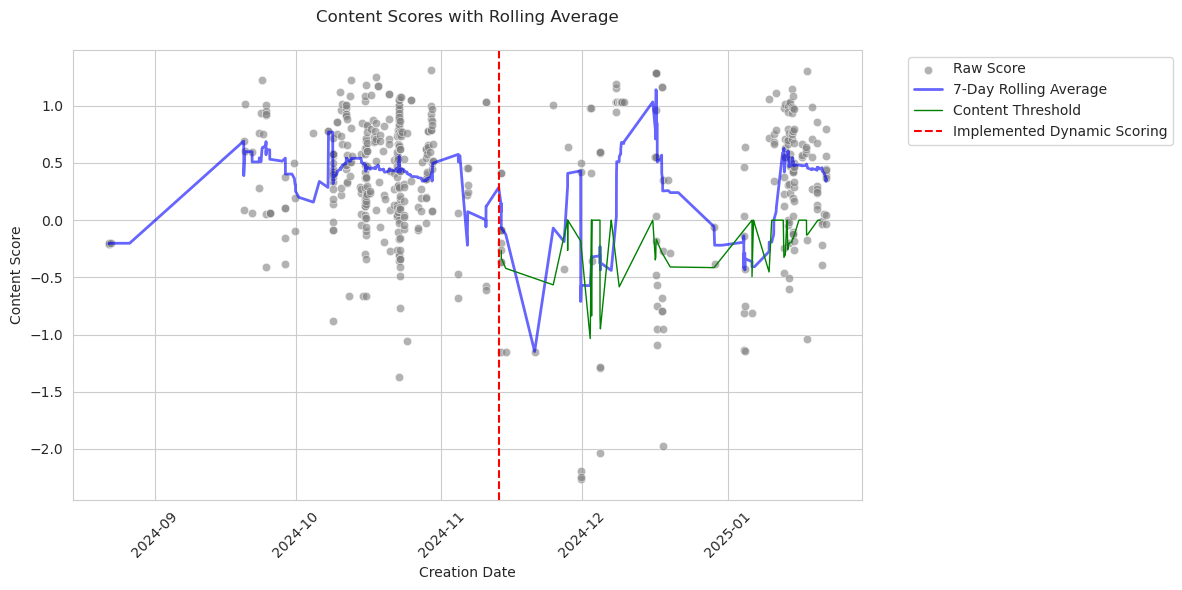

In [8]:
df = df.sort_values('created_at')

# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Create the main line plot
sns.scatterplot(data=df, x='created_at', y='content', 
             label='Raw Score', alpha=0.6, color='gray')

# Calculate and plot rolling average (7-day window)
rolling_avg = df['content'].rolling(window="7D", min_periods=1).mean()
sns.lineplot(x=df.index, y=rolling_avg, 
             label='7-Day Rolling Average', 
             color='blue', linewidth=2, alpha=0.6)

# Draw Threshold
sns.lineplot(data=df.loc[(df.score_history.str.len() == 0)], x='created_at', y='metrics.content.threshold', 
             label='Content Threshold', 
             color='green', linewidth=1, alpha=1)

# Customize the plot
plt.title('Content Scores with Rolling Average', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Indicate when we started dynamic scoring
implementation_date = pd.to_datetime("2024-11-13 05:17:11.410141+00")
plt.axvline(
    implementation_date,
    color="red",
    linestyle="--",
    label="Implemented Dynamic Scoring"
)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [9]:
(df.content < df["metrics.content.threshold"]).loc[
    df.index >= pd.to_datetime("2025-01-01 05:17:11.410141+00")
].describe()

count       169
unique        2
top       False
freq        154
dtype: object

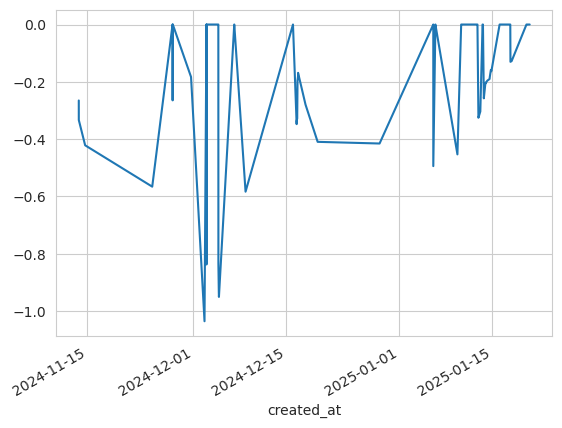

In [13]:
df_no_score_history = df.loc[
    (df.score_history.str.len() == 0)
    & (df.index >= pd.to_datetime("2024-11-13 05:17:11.410141+00"))
]
df_no_score_history["metrics.content.threshold"].plot();